In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [2]:
DATASET_DIR = r"C:\Users\zeroh\OneDrive\Desktop\vv\violence_dataset"

IMG_SIZE = (224, 224)   # works well with most CNNs
BATCH_SIZE = 32


In [5]:

from tensorflow.keras.layers import Dense, Flatten, Dropout



In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    shear_range=0.2,
    brightness_range=[0.6,1.4],
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 8851 images belonging to 2 classes.
Found 2212 images belonging to 2 classes.


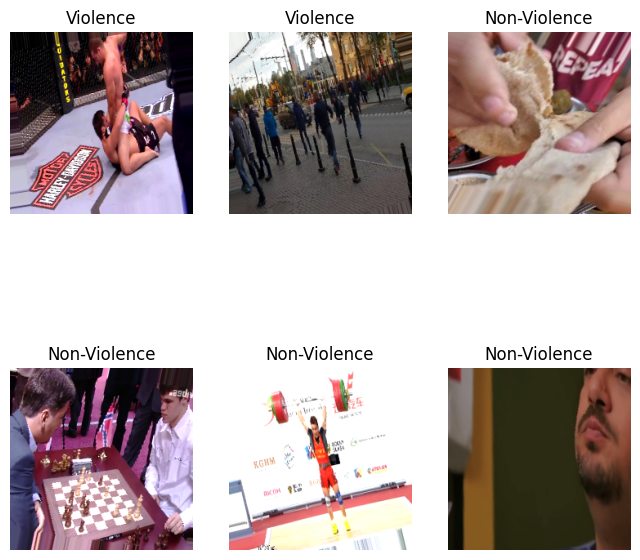

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Violence" if labels[i]==1 else "Non-Violence")
    plt.axis("off")
plt.show()


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 1.0574671445639188, 1: 0.9484569224174882}


In [9]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Phase 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


In [10]:
from tensorflow.keras.metrics import Precision, Recall
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]


In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/30
277/277 [==============================] - 85s 283ms/step - loss: 0.4998 - accuracy: 0.7527 - precision: 0.7644 - recall: 0.7675 - val_loss: 0.3121 - val_accuracy: 0.8915 - val_precision: 0.8795 - val_recall: 0.9202 - lr: 1.0000e-04
Epoch 2/30
277/277 [==============================] - 79s 286ms/step - loss: 0.3707 - accuracy: 0.8370 - precision: 0.8468 - recall: 0.8433 - val_loss: 0.2720 - val_accuracy: 0.9001 - val_precision: 0.8921 - val_recall: 0.9220 - lr: 1.0000e-04
Epoch 3/30
277/277 [==============================] - 80s 290ms/step - loss: 0.3178 - accuracy: 0.8645 - precision: 0.8753 - recall: 0.8665 - val_loss: 0.2683 - val_accuracy: 0.8983 - val_precision: 0.8937 - val_recall: 0.9160 - lr: 1.0000e-04
Epoch 4/30
277/277 [==============================] - 84s 305ms/step - loss: 0.2958 - accuracy: 0.8748 - precision: 0.8827 - recall: 0.8793 - val_loss: 0.2731 - val_accuracy: 0.8960 - val_precision: 0.9239 - val_recall: 0.8748 - lr: 1.0000e-04
Epoch 5/30
277/277 [====

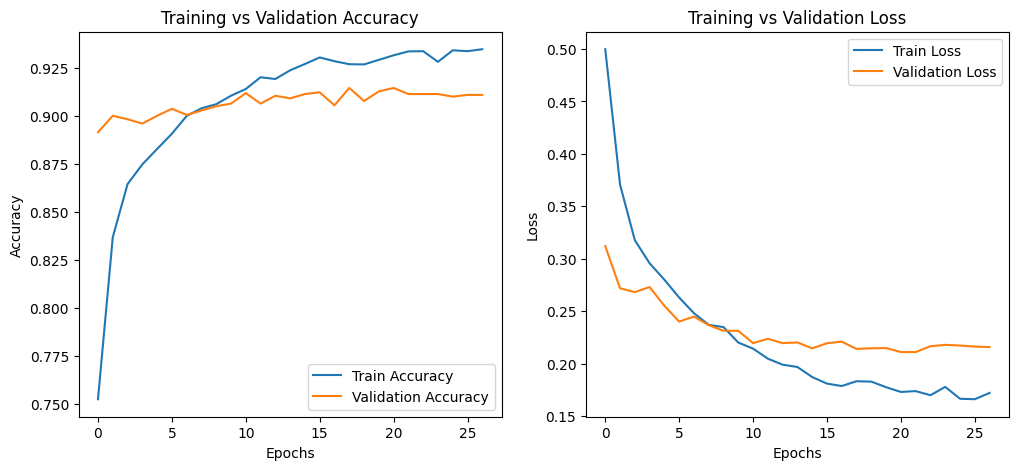

In [13]:
# Accuracy graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [14]:
model.save("violence_cnn_mobilenetv2(1).h5")


In [15]:
import cv2
import numpy as np
import tensorflow as tf
import os
import time
from datetime import datetime
from collections import deque

# Load model
model = tf.keras.models.load_model("violence_cnn_mobilenetv2(1).h5")

IMG_SIZE = 224
THRESHOLD = 0.6
VOTE_FRAMES = 10
COOLDOWN = 5  # seconds between saves

pred_queue = deque(maxlen=VOTE_FRAMES)

SAVE_FOLDER = "violence_frames"
os.makedirs(SAVE_FOLDER, exist_ok=True)

last_saved_time = 0  # track last save timestamp

cap = cv2.VideoCapture(0)
print("✅ Webcam started. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0][0]
    pred_queue.append(pred)
    avg_pred = np.mean(pred_queue)

    current_time = time.time()

    if avg_pred > THRESHOLD:
        label = "VIOLENCE"
        color = (0, 0, 255)

        # Save only if cooldown passed
        if current_time - last_saved_time > COOLDOWN:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{SAVE_FOLDER}/violence_{timestamp}.jpg"
            cv2.imwrite(filename, frame)
            print(f"📸 Saved: {filename}")
            last_saved_time = current_time

    else:
        label = "NON-VIOLENCE"
        color = (0, 255, 0)

    text = f"{label} ({avg_pred:.2f})"
    cv2.putText(frame, text, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    cv2.imshow("Violence Detection (Webcam)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


✅ Webcam started. Press 'q' to quit.
